<a href="https://colab.research.google.com/github/Anish-185/iris_dataset/blob/main/Iris_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

In [ ]:
data=load_iris()

In [ ]:
X=pd.DataFrame(data.data,columns=data.feature_names)


In [ ]:
X_copy=X.copy()
X_copy.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0


In [ ]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
X_copy.iloc[10:15,2]=np.nan
X_copy.iloc[30:35,1]=np.nan

In [ ]:
X_copy.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),5
petal length (cm),5
petal width (cm),0


In [ ]:
np.size(X_copy)

600

In [ ]:
X.shape

(150, 4)

In [ ]:
print("before handling missing values : ")
print(X_copy.isnull().sum())

before handling missing values : 
sepal length (cm)    0
sepal width (cm)     5
petal length (cm)    5
petal width (cm)     0
dtype: int64


In [ ]:
print("after handling missing values : ")
print(X_copy.fillna(X_copy.mean(),inplace=True))

after handling missing values : 
None


In [ ]:
print(X_copy.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


In [ ]:
X_copy.shape

(150, 4)

In [ ]:
from scipy.stats import zscore

In [ ]:
z_scores=np.abs(zscore(X_copy))

In [ ]:
X_cleaned=X_copy[(z_scores < threshold).all(axis=1)]

In [ ]:
print(X_cleaned)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[149 rows x 4 columns]


In [ ]:
X_cleaned.shape

(149, 4)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_987/4273020785.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


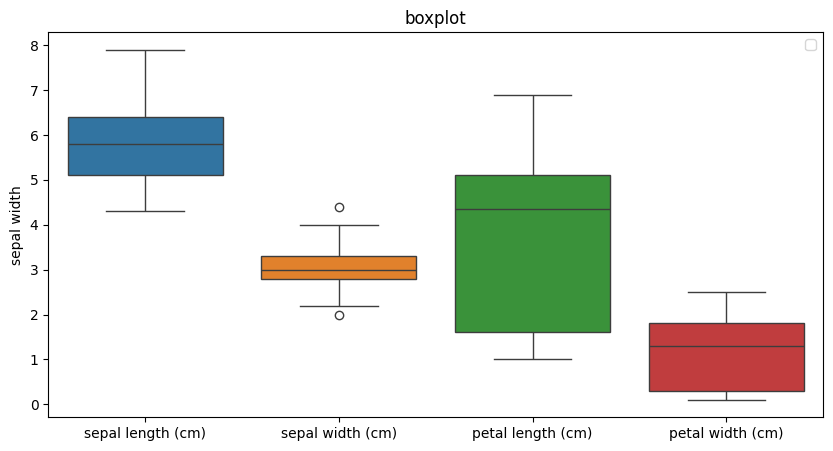

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=X_copy)
plt.title("boxplot")
plt.ylabel("sepal width")
plt.legend()
plt.show()

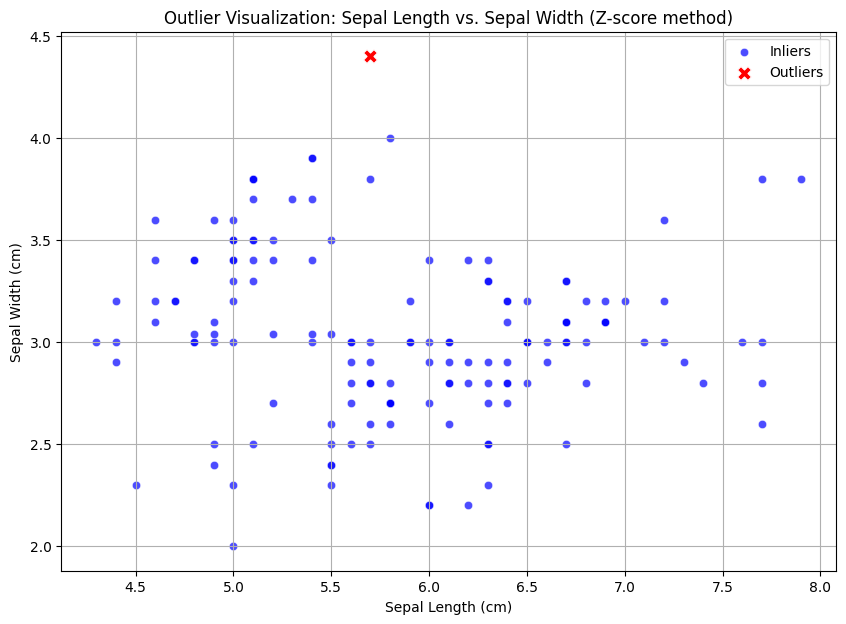

In [ ]:
X_inliers = X_copy[~outlier_mask]
X_outliers = X_copy[outlier_mask]

plt.figure(figsize=(10, 7))

sns.scatterplot(x=X_inliers['sepal length (cm)'], y=X_inliers['sepal width (cm)'], label='Inliers', color='blue', alpha=0.7)

sns.scatterplot(x=X_outliers['sepal length (cm)'], y=X_outliers['sepal width (cm)'], label='Outliers', color='red', marker='X', s=100)

plt.title('Outlier Visualization: Sepal Length vs. Sepal Width (Z-score method)')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend()
plt.grid(True)
plt.show()